# Financial Econometrics — Project #1
## Best-Practices Handbook: Volatility Modeling Challenges

**Course:** HASTS 201 — Financial Econometrics  
**Dataset:** Yahoo Finance Daily Stock Price Data (2018-01-02 to 2025-12-31)

---

### Challenges Addressed

| # | Challenge |
|---|---|
| 1 | **Skewness** |
| 2 | **Sensitivity to Outliers** |
| 3 | **Overfitting** |
| 4 | **Multicollinearity** |

---

## Setup & Data Loading (Downloading from API)

In [53]:
# ── Core Libraries ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
import requests
import pandas as pd
from datetime import datetime
warnings.filterwarnings('ignore')

# ── Statistical / Econometric Libraries ─────────────────────────────────────
import scipy.stats as stats
from scipy.stats import jarque_bera, skewnorm, t as t_dist
import statsmodels.api as sm
from statsmodels.stats.stattools import jarque_bera as jb_sm
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error
from arch import arch_model

# ── Plot Style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans'
})
BLUE, RED, GREEN, ORANGE = '#2166ac', '#d6604d', '#1a9641', '#f4a40a'

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [54]:
# ── Load Data (Data Download) ────────────────────────────────────────────────────────────────
SYMBOL = "AAPL"
START  = int(datetime(2018, 1, 1).timestamp())
END    = int(datetime(2025, 12, 31).timestamp())

# ── Headers (required — Yahoo blocks requests without User-Agent) ──────────────
HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/124.0.0.0 Safari/537.36"
    ),
    "Accept": "application/json, text/plain, */*",
    "Accept-Language": "en-US,en;q=0.9",
    "Referer": "https://finance.yahoo.com/",
}

# ── Step 1: Open a session and grab the crumb (required since 2023) ───────────
session = requests.Session()
session.headers.update(HEADERS)

# Visit the main page first so Yahoo sets the session cookie
session.get("https://finance.yahoo.com", timeout=10)

# Fetch the crumb token
crumb_resp = session.get(
    "https://query1.finance.yahoo.com/v1/test/getcrumb",
    timeout=10
)
crumb = crumb_resp.text.strip()
print(f"✅  Crumb: {crumb!r}")

# ── Step 2: Fetch historical data ─────────────────────────────────────────────
# FIX: single clean URL — no duplicate, no ?range=1y conflict
url = f"https://query1.finance.yahoo.com/v8/finance/chart/{SYMBOL}"

params = {
    "period1":  START,
    "period2":  END,
    "interval": "1d",
    "events":   "history",
    "crumb":    crumb,   # FIX: attach crumb
}

response = session.get(url, params=params, timeout=15)
response.raise_for_status()      # raises HTTPError on 4xx/5xx
data = response.json()

# ── Step 3: Parse JSON ────────────────────────────────────────────────────────
result     = data["chart"]["result"][0]
timestamps = result["timestamp"]
quotes     = result["indicators"]["quote"][0]
adj_close  = result["indicators"].get("adjclose", [{}])[0].get("adjclose", [None]*len(timestamps))

df = pd.DataFrame({
    "Date":      pd.to_datetime(timestamps, unit="s").normalize(),
    "Open":      quotes["open"],
    "High":      quotes["high"],
    "Low":       quotes["low"],
    "Close":     quotes["close"],
    "Adj Close": adj_close,
    "Volume":    quotes["volume"],
})

# Round price columns to 2 decimal places
for col in ["Open", "High", "Low", "Close", "Adj Close"]:
    df[col] = df[col].round(2)

df["Date"] = df["Date"].dt.strftime("%Y-%m-%d")

print(f"\n✅  Rows fetched: {len(df)}")
print(df.tail(6).to_string(index=False))



✅  Crumb: '{"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Cookie"}}}'

✅  Rows fetched: 2010
      Date   Open   High    Low  Close  Adj Close   Volume
2025-12-22 272.86 273.88 270.51 270.97     270.72 36571800
2025-12-23 270.84 272.50 269.56 272.36     272.11 29642000
2025-12-24 272.34 275.43 272.20 273.81     273.55 17910600
2025-12-26 274.16 275.37 272.86 273.40     273.14 21521800
2025-12-29 272.69 274.36 272.35 273.76     273.50 23715200
2025-12-30 272.81 274.08 272.28 273.08     272.82 22139600


In [61]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# ── Feature Engineering ──────────────────────────────────────────────────────
df['Returns']      = df['Adj Close'].pct_change()          # simple daily return
df['LogReturns']   = np.log(df['Adj Close'] / df['Adj Close'].shift(1))
df['Range']        = df['High'] - df['Low']               # intraday range
df['MA5']          = df['Adj Close'].rolling(5).mean()
df['MA20']         = df['Adj Close'].rolling(20).mean()
df['MA60']         = df['Adj Close'].rolling(60).mean()
df['RealVol20']    = df['LogReturns'].rolling(20).std() * np.sqrt(252)  # annualised
df['RealVol5']     = df['LogReturns'].rolling(5).std()  * np.sqrt(252)
df['Volume_MA20']  = df['Volume'].rolling(20).mean()
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Rows after cleaning : {len(df)}')
print(f'Date range          : {df.Date.min().date()} → {df.Date.max().date()}')
df[['Date','Adj Close','Returns','LogReturns','RealVol20']].head()

Rows after cleaning : 1951
Date range          : 2018-03-28 → 2025-12-30


,Date,Adj Close,Returns,LogReturns,RealVol20
0,2018-03-28,39.11,-0.011125,-0.011188,0.267108
1,2018-03-29,39.42,0.007926,0.007895,0.264243
2,2018-04-02,39.16,-0.006596,-0.006617,0.262424
3,2018-04-03,39.56,0.010215,0.010163,0.265622
4,2018-04-04,40.32,0.019211,0.019029,0.276361


---
# Challenge 1 — Skewness

---

## 1.1 Definition

Skewness is the **third standardised central moment** of a distribution. For a random variable $r$ with mean $\mu$ and standard deviation $\sigma$:

$$
\text{Skewness} = \frac{\mathbb{E}\left[(r - \mu)^3\right]}{\sigma^3}
= \frac{\frac{1}{n}\sum_{t=1}^{n}(r_t - \bar{r})^3}{\left[\frac{1}{n}\sum_{t=1}^{n}(r_t - \bar{r})^2\right]^{3/2}}
$$

| Value | Shape |
|---|---|
| $= 0$ | Symmetric (Normal) |
| $> 0$ | Right-skewed (positive tail) |
| $< 0$ | Left-skewed (negative tail) — **common in equity returns** |

## 1.2 Description

Skewness measures the **asymmetry** of the return distribution around its mean. In equity markets, returns tend to exhibit **negative skewness** — large losses are more frequent and more extreme than large gains — which directly undermines volatility models that assume normally distributed returns (e.g., Black-Scholes).

## 1.3 Demonstration

In [62]:
r = df['LogReturns']

# ── Descriptive Stats ────────────────────────────────────────────────────────
skew_val  = r.skew()
kurt_val  = r.kurt()   # excess kurtosis
jb_stat, jb_p = jarque_bera(r)

print('=' * 45)
print('   Log-Return Distribution Statistics')
print('=' * 45)
print(f'  Observations     : {len(r):,}')
print(f'  Mean             : {r.mean():.6f}')
print(f'  Std Dev (daily)  : {r.std():.6f}')
print(f'  Skewness         : {skew_val:.4f}')
print(f'  Excess Kurtosis  : {kurt_val:.4f}  (Normal = 0)')
print(f'  Jarque-Bera Stat : {jb_stat:.2f}')
print(f'  JB p-value       : {jb_p:.2e}')
print(f'  5th Percentile   : {r.quantile(0.05):.4f}')
print(f'  95th Percentile  : {r.quantile(0.95):.4f}')
print('=' * 45)
print(f'\n  Interpretation: Skewness = {skew_val:.4f}')
if skew_val < 0:
    print('  The distribution is LEFT-SKEWED (negative tail).')
    print('  Extreme negative returns are more likely than a')
    print('  normal distribution would predict.')
else:
    print('  The distribution is RIGHT-SKEWED (positive tail).')

   Log-Return Distribution Statistics
  Observations     : 1,951
  Mean             : 0.000990
  Std Dev (daily)  : 0.019445
  Skewness         : -0.0953
  Excess Kurtosis  : 6.3001  (Normal = 0)
  Jarque-Bera Stat : 3209.90
  JB p-value       : 0.00e+00
  5th Percentile   : -0.0304
  95th Percentile  : 0.0288

  Interpretation: Skewness = -0.0953
  The distribution is LEFT-SKEWED (negative tail).
  Extreme negative returns are more likely than a
  normal distribution would predict.


## 1.4 Diagram

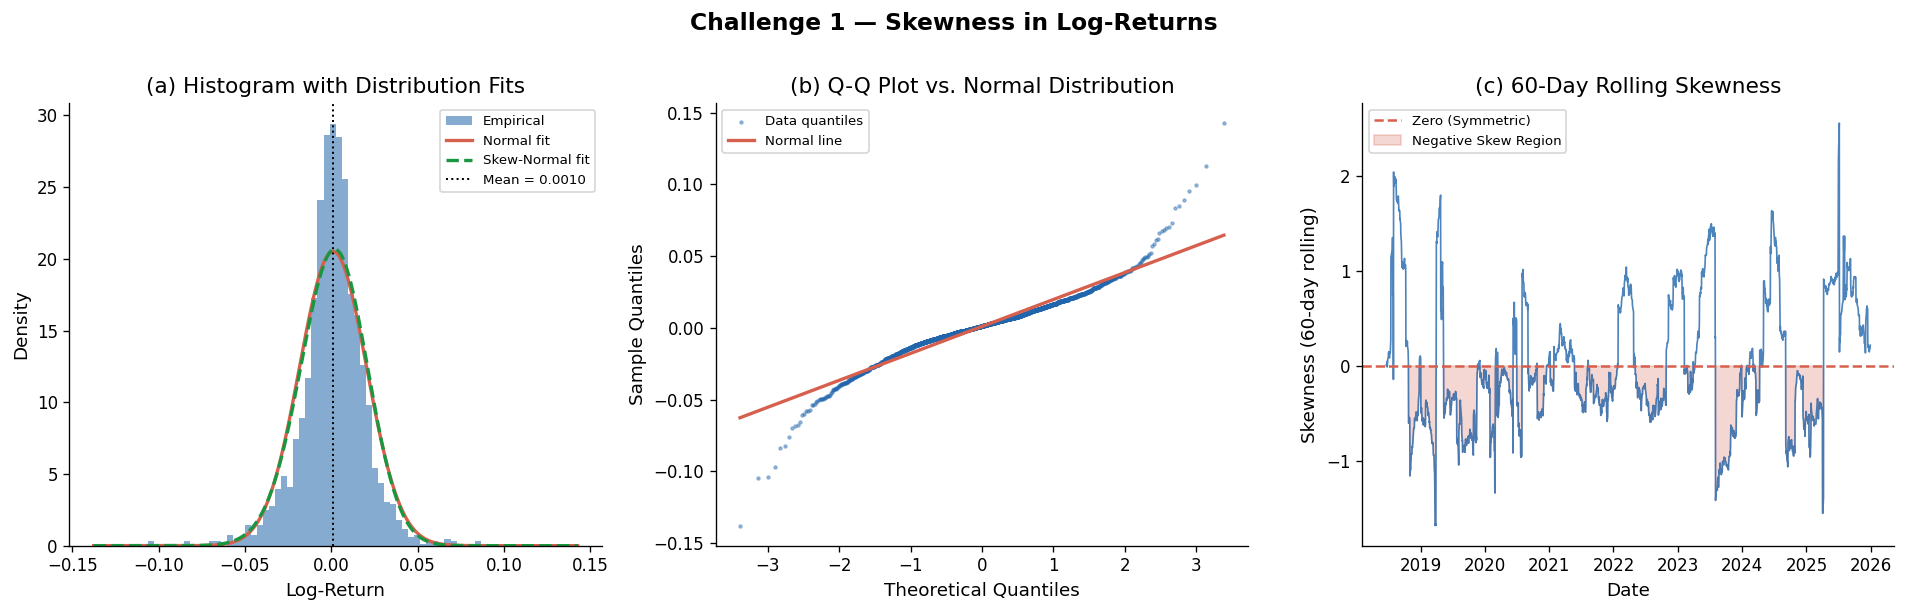

Figure 1 saved.


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Challenge 1 — Skewness in Log-Returns', fontsize=14, fontweight='bold', y=1.01)

# ── (a) Histogram vs Normal Fit ───────────────────────────────────────────────
ax = axes[0]
x  = np.linspace(r.min(), r.max(), 400)
ax.hist(r, bins=80, density=True, color=BLUE, alpha=0.55, label='Empirical')
mu, sig = r.mean(), r.std()
ax.plot(x, stats.norm.pdf(x, mu, sig), color=RED, lw=2, label='Normal fit')
# skew-normal fit
a_fit, loc_fit, scale_fit = skewnorm.fit(r)
ax.plot(x, skewnorm.pdf(x, a_fit, loc_fit, scale_fit), color=GREEN, lw=2,
        linestyle='--', label='Skew-Normal fit')
ax.axvline(mu, color='k', linestyle=':', lw=1.2, label=f'Mean = {mu:.4f}')
ax.set_xlabel('Log-Return'); ax.set_ylabel('Density')
ax.set_title('(a) Histogram with Distribution Fits')
ax.legend(fontsize=8)

# ── (b) Q-Q Plot ──────────────────────────────────────────────────────────────
ax = axes[1]
(osm, osr), (slope, intercept, _) = stats.probplot(r, dist='norm')
ax.scatter(osm, osr, s=3, alpha=0.4, color=BLUE, label='Data quantiles')
ax.plot(osm, slope * np.array(osm) + intercept, color=RED, lw=2, label='Normal line')
ax.set_xlabel('Theoretical Quantiles'); ax.set_ylabel('Sample Quantiles')
ax.set_title('(b) Q-Q Plot vs. Normal Distribution')
ax.legend(fontsize=8)

# ── (c) Rolling Skewness Over Time ────────────────────────────────────────────
ax = axes[2]
rolling_skew = df['LogReturns'].rolling(60).skew()
ax.plot(df['Date'], rolling_skew, color=BLUE, lw=1.0, alpha=0.8)
ax.axhline(0, color=RED, linestyle='--', lw=1.5, label='Zero (Symmetric)')
ax.fill_between(df['Date'], rolling_skew, 0, where=(rolling_skew < 0),
                alpha=0.25, color=RED, label='Negative Skew Region')
ax.set_xlabel('Date'); ax.set_ylabel('Skewness (60-day rolling)')
ax.set_title('(c) 60-Day Rolling Skewness')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig1_skewness.png', bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

## 1.5 Diagnosis

Three complementary tests are used to detect skewness:

In [31]:
# ── Test 1: Jarque-Bera (tests joint normality via skewness + kurtosis) ───────
jb_stat, jb_p = jarque_bera(r)

# ── Test 2: D'Agostino-Pearson (skewness-only component) ─────────────────────
skew_stat, skew_p = stats.skewtest(r)

# ── Test 3: Kolmogorov-Smirnov test against Normal ───────────────────────────
ks_stat, ks_p = stats.kstest(r, 'norm', args=(r.mean(), r.std()))

print('Skewness Diagnostic Tests')
print('─' * 55)
print(f'  Sample Skewness              : {r.skew():.4f}')
print(f'  Jarque-Bera  stat            : {jb_stat:>10.2f}  p = {jb_p:.2e}')
print(f'  D\'Agostino Skewness stat     : {skew_stat:>10.4f}  p = {skew_p:.2e}')
print(f'  Kolmogorov-Smirnov stat      : {ks_stat:>10.4f}  p = {ks_p:.2e}')
print('─' * 55)
alpha = 0.05
for name, p in [('Jarque-Bera', jb_p), ('D\'Agostino', skew_p), ('KS-test', ks_p)]:
    verdict = 'REJECT normality' if p < alpha else 'FAIL TO REJECT normality'
    print(f'  {name:<20}: {verdict} (α = {alpha})')

Skewness Diagnostic Tests
───────────────────────────────────────────────────────
  Sample Skewness              : -0.0953
  Jarque-Bera  stat            :    3210.07  p = 0.00e+00
  D'Agostino Skewness stat     :    -1.7206  p = 8.53e-02
  Kolmogorov-Smirnov stat      :     0.0777  p = 1.09e-10
───────────────────────────────────────────────────────
  Jarque-Bera         : REJECT normality (α = 0.05)
  D'Agostino          : FAIL TO REJECT normality (α = 0.05)
  KS-test             : REJECT normality (α = 0.05)


## 1.6 Damage

Ignoring skewness in financial returns causes **systematic mispricing and risk underestimation**:

- **Options Pricing**: The Black-Scholes model assumes symmetric log-normal returns. Negative skewness generates the **volatility smile / skew**, so put options are consistently underpriced relative to calls.
- **Value at Risk (VaR)**: Normal-distribution VaR underestimates left-tail risk — e.g., a 1% VaR estimated under normality may truly correspond to a 2–3% empirical probability of loss.
- **Portfolio Optimization**: Mean-variance optimisation ignores the asymmetry; portfolios appear safer than they are, leading to under-hedging.

## 1.7 Directions

In [32]:
# ── Direction A: Fit a Skew-Normal Distribution ───────────────────────────────
a_hat, loc_hat, scale_hat = skewnorm.fit(r)
print('Skew-Normal Parameters:')
print(f'  Shape (α)  : {a_hat:.4f}  (negative ⟹ left-skewed)')
print(f'  Location   : {loc_hat:.6f}')
print(f'  Scale      : {scale_hat:.6f}')

# ── Direction B: Fit a Student-t (handles heavy tails & mild skew) ─────────────
df_t, loc_t, scale_t = t_dist.fit(r)
print(f'\nStudent-t Degrees of Freedom: {df_t:.4f}')
print(f'  (df < 30 confirms heavy tails, typical for equity returns)')

# ── Direction C: GJR-GARCH with skewed-t innovations ─────────────────────────
returns_scaled = r * 100   # arch prefers percentage returns
gjr = arch_model(returns_scaled, vol='Garch', p=1, o=1, q=1, dist='skewt')
res_gjr = gjr.fit(disp='off')
print('\nGJR-GARCH(1,1,1) with Skewed-t innovations:')
print(res_gjr.summary().tables[1])

Skew-Normal Parameters:
  Shape (α)  : -0.8820  (negative ⟹ left-skewed)
  Location   : 0.012970
  Scale      : 0.022835

Student-t Degrees of Freedom: 3.2447
  (df < 30 confirms heavy tails, typical for equity returns)

GJR-GARCH(1,1,1) with Skewed-t innovations:
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.1130  3.553e-02      3.180  1.474e-03 [4.334e-02,  0.183]



GJR-GARCH(1,1,1) with Skewed-t innovations:


                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.1059  3.505e-02      3.021  2.521e-03 [3.718e-02,  0.175]


In [33]:
# ── VaR Comparison: Normal vs Skew-t (Direction D) ────────────────────────────
conf_levels = [0.95, 0.99]
print('\nVaR Comparison (1-day horizon):')
print(f'{"Level":<8} {"Normal VaR":>12} {"Empirical VaR":>15} {"Underestimation":>18}')
print('─' * 56)
for cl in conf_levels:
    var_norm = stats.norm.ppf(1-cl, r.mean(), r.std())
    var_emp  = r.quantile(1-cl)
    diff     = var_emp - var_norm
    print(f'{cl:.0%}    {var_norm:>12.4f} {var_emp:>15.4f} {diff:>18.4f}')

print('\nConclusion: Normal VaR underestimates losses in the left tail.')
print('Recommended models to address skewness:')
print('  1. GJR-GARCH / EGARCH with skewed-t distribution')
print('  2. Cornish-Fisher VaR expansion (adjusts for skewness & kurtosis)')
print('  3. Extreme Value Theory (EVT) / Peaks-Over-Threshold (POT)')
print('  4. Jump-Diffusion models (Merton 1976)')


VaR Comparison (1-day horizon):
Level      Normal VaR   Empirical VaR    Underestimation
────────────────────────────────────────────────────────
95%         -0.0310         -0.0304             0.0006
99%         -0.0442         -0.0514            -0.0072

Conclusion: Normal VaR underestimates losses in the left tail.
Recommended models to address skewness:
  1. GJR-GARCH / EGARCH with skewed-t distribution
  2. Cornish-Fisher VaR expansion (adjusts for skewness & kurtosis)
  3. Extreme Value Theory (EVT) / Peaks-Over-Threshold (POT)
  4. Jump-Diffusion models (Merton 1976)


---
# Challenge 2 — Sensitivity to Outliers

---

## 2.1 Definition

An observation $r_t$ is a statistical **outlier** if it falls beyond a threshold defined by the Interquartile Range (IQR):

$$
r_t \text{ is an outlier if } r_t < Q_1 - k \cdot \text{IQR} \quad \text{or} \quad r_t > Q_3 + k \cdot \text{IQR},
\quad \text{IQR} = Q_3 - Q_1, \quad k = 1.5 \text{ (mild)},\ 3.0 \text{ (extreme)}
$$

In regression, outlier **influence** is measured by **Cook's Distance**:

$$
D_i = \frac{\sum_{j=1}^{n}(\hat{y}_j - \hat{y}_{j(i)})^2}{p \cdot \text{MSE}}
$$

where $\hat{y}_{j(i)}$ is the fitted value after removing observation $i$, and $p$ is the number of parameters. A rule-of-thumb is $D_i > 4/n$ signals a highly influential point.

## 2.2 Description

Sensitivity to outliers occurs when a small number of extreme observations (e.g., crash-day returns) **disproportionately distort** model estimates, pulling regression coefficients and volatility forecasts away from values that represent the bulk of the data. Because OLS minimises the sum of **squared** residuals, a single extreme return can dominate the entire regression fit.

## 2.3 Demonstration

In [34]:
# ── Identify Outliers via IQR ─────────────────────────────────────────────────
r2 = df['LogReturns'].copy()
Q1, Q3 = r2.quantile(0.25), r2.quantile(0.75)
IQR    = Q3 - Q1

mild_lo,  mild_hi  = Q1 - 1.5*IQR, Q3 + 1.5*IQR
extr_lo,  extr_hi  = Q1 - 3.0*IQR, Q3 + 3.0*IQR

mild_mask  = (r2 < mild_lo) | (r2 > mild_hi)
extr_mask  = (r2 < extr_lo) | (r2 > extr_hi)

print('Outlier Summary (Log-Returns)')
print('─' * 50)
print(f'  Q1             : {Q1:.6f}')
print(f'  Q3             : {Q3:.6f}')
print(f'  IQR            : {IQR:.6f}')
print(f'  Mild fence     : [{mild_lo:.4f}, {mild_hi:.4f}]')
print(f'  Extreme fence  : [{extr_lo:.4f}, {extr_hi:.4f}]')
print(f'  Mild outliers  : {mild_mask.sum()} ({mild_mask.mean():.2%})')
print(f'  Extreme outliers: {extr_mask.sum()} ({extr_mask.mean():.2%})')

# ── Top 5 Extreme Returns ─────────────────────────────────────────────────────
top5_neg = df.loc[r2.nsmallest(5).index, ['Date','LogReturns']]
top5_pos = df.loc[r2.nlargest(5).index, ['Date','LogReturns']]
print('\nTop 5 Negative Outliers:')
print(top5_neg.to_string(index=False))
print('\nTop 5 Positive Outliers:')
print(top5_pos.to_string(index=False))

Outlier Summary (Log-Returns)
──────────────────────────────────────────────────
  Q1             : -0.007832
  Q3             : 0.011004
  IQR            : 0.018836
  Mild fence     : [-0.0361, 0.0393]
  Extreme fence  : [-0.0643, 0.0675]
  Mild outliers  : 105 (5.38%)
  Extreme outliers: 22 (1.13%)

Top 5 Negative Outliers:
      Date  LogReturns
2020-03-16   -0.137709
2019-01-03   -0.104768
2020-03-12   -0.103942
2025-04-03   -0.097012
2020-09-03   -0.083419

Top 5 Positive Outliers:
      Date  LogReturns
2025-04-09    0.142642
2020-03-13    0.113067
2020-07-31    0.099573
2020-03-24    0.095629
2020-03-02    0.089028


In [35]:
# ── OLS with vs. without outliers ─────────────────────────────────────────────
lag_df = pd.DataFrame({
    'r_t'   : r2.values[1:],
    'r_lag1': r2.values[:-1]
}).reset_index(drop=True)
lag_df.dropna(inplace=True)

X_all = sm.add_constant(lag_df['r_lag1'])
y_all = lag_df['r_t']

# align mild_mask to lag_df (lag_df has one fewer row, offset by 1)
mild_lag   = mild_mask.values[1:]             # boolean, same length as lag_df
lag_clean  = lag_df[~mild_lag].copy()
X_cln = sm.add_constant(lag_clean['r_lag1'])
y_cln = lag_clean['r_t']

ols_all = OLS(y_all, X_all).fit()
ols_cln = OLS(y_cln, X_cln).fit()

print('OLS Coefficient Comparison (AR(1) on Log-Returns)')
print('─' * 55)
print(f'{"":<20} {"With Outliers":>15} {"Without Outliers":>17}')
print(f'{"Intercept":<20} {ols_all.params["const"]:>15.6f} {ols_cln.params["const"]:>17.6f}')
print(f'{"Lag Coeff (β₁)":<20} {ols_all.params["r_lag1"]:>15.6f} {ols_cln.params["r_lag1"]:>17.6f}')
print(f'{"R-squared":<20} {ols_all.rsquared:>15.6f} {ols_cln.rsquared:>17.6f}')
print(f'{"RMSE":<20} {np.sqrt(ols_all.mse_resid):>15.6f} {np.sqrt(ols_cln.mse_resid):>17.6f}')
print(f'{"N (obs)":<20} {ols_all.nobs:>15.0f} {ols_cln.nobs:>17.0f}')

OLS Coefficient Comparison (AR(1) on Log-Returns)
───────────────────────────────────────────────────────
                       With Outliers  Without Outliers
Intercept                   0.001066          0.001536
Lag Coeff (β₁)             -0.070864          0.004023
R-squared                   0.005023          0.000026
RMSE                        0.019404          0.014222
N (obs)                         1950              1845


## 2.4 Diagram

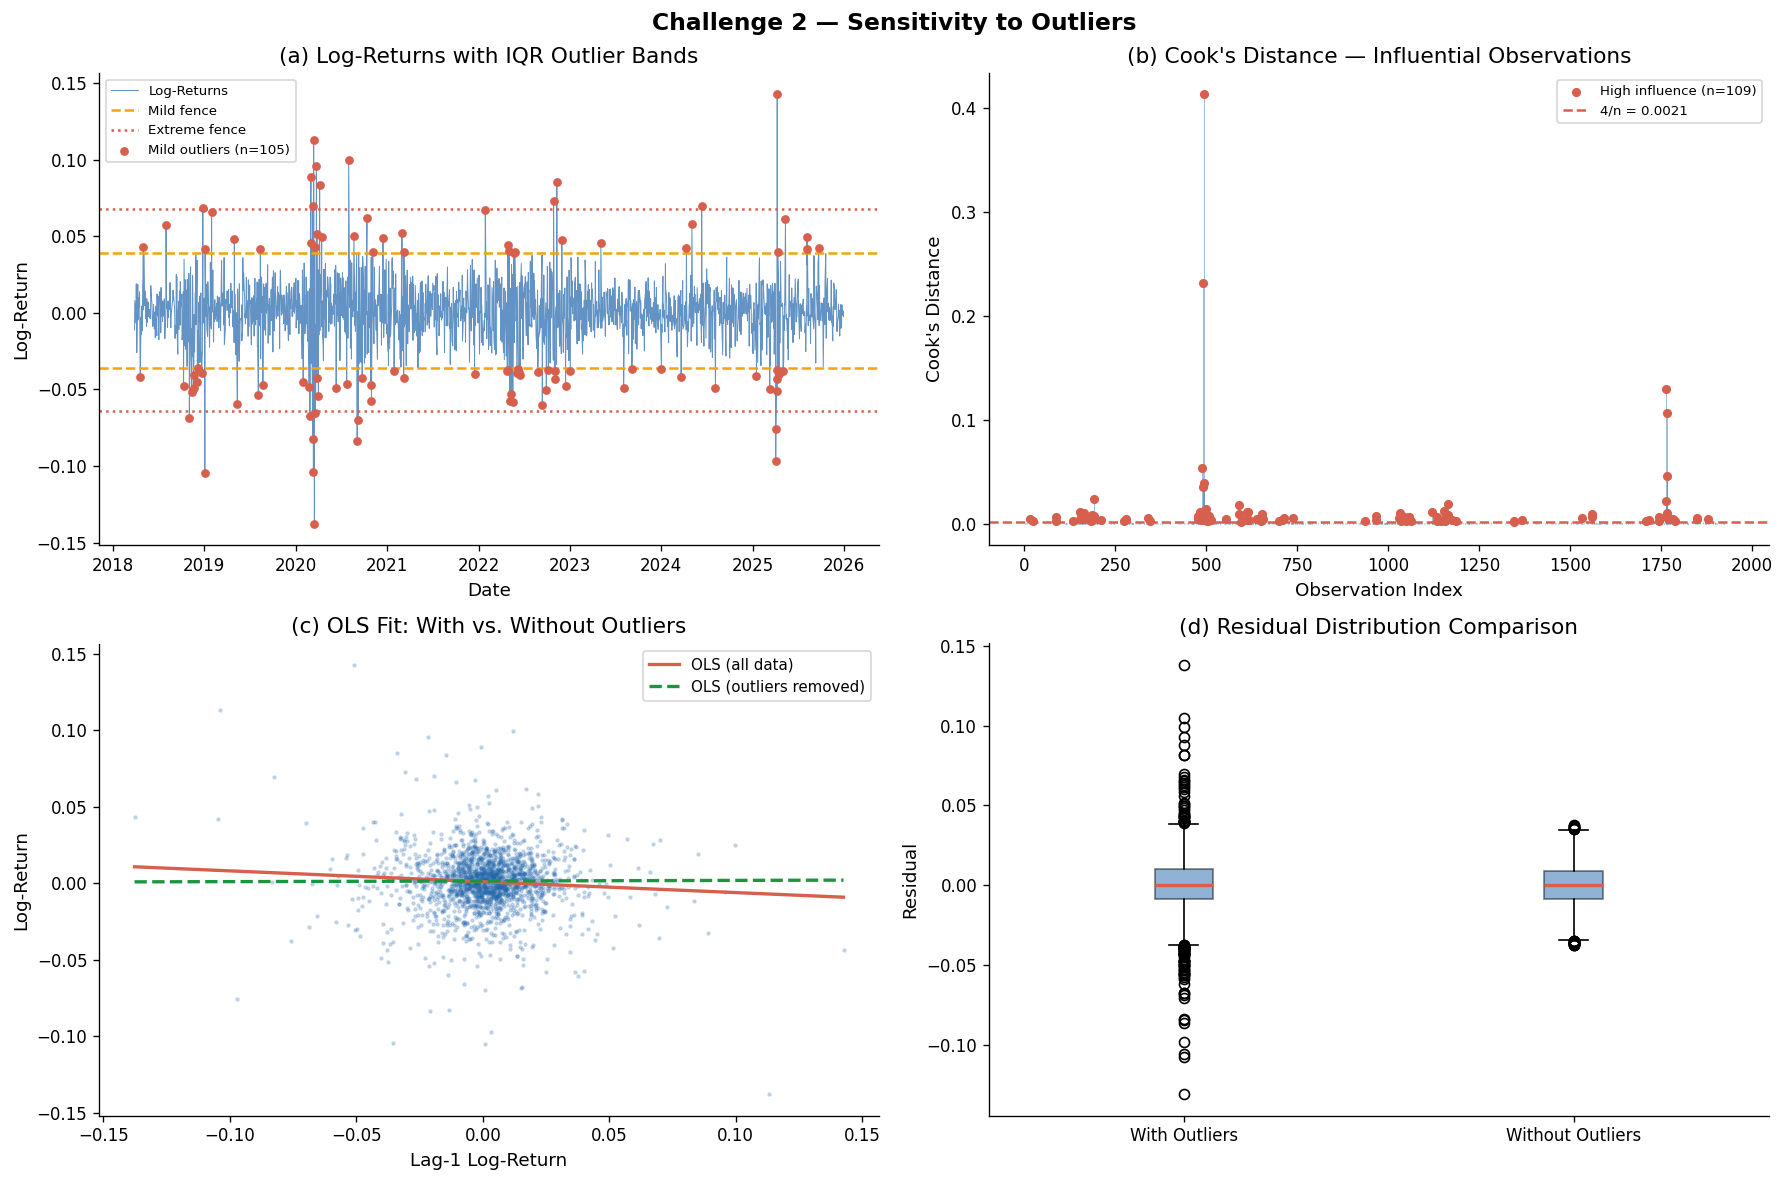

Figure 2 saved.


In [38]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Challenge 2 — Sensitivity to Outliers', fontsize=14, fontweight='bold')

# ── (a) Return series with outlier bands ─────────────────────────────────────
ax = axes[0, 0]
ax.plot(df['Date'], r2.values, color=BLUE, lw=0.6, alpha=0.7, label='Log-Returns')
ax.axhline(mild_lo, color=ORANGE, lw=1.5, linestyle='--', label='Mild fence')
ax.axhline(mild_hi, color=ORANGE, lw=1.5, linestyle='--')
ax.axhline(extr_lo, color=RED, lw=1.5, linestyle=':', label='Extreme fence')
ax.axhline(extr_hi, color=RED, lw=1.5, linestyle=':')
out_dates = df.loc[mild_mask.values, 'Date']
out_vals  = r2.values[mild_mask.values]
ax.scatter(out_dates, out_vals, color=RED, s=18, zorder=5, label=f'Mild outliers (n={mild_mask.sum()})')
ax.set_title('(a) Log-Returns with IQR Outlier Bands')
ax.set_xlabel('Date'); ax.set_ylabel('Log-Return')
ax.legend(fontsize=8)

# ── (b) Cook's Distance ───────────────────────────────────────────────────────
ax = axes[0, 1]
influence = ols_all.get_influence()
cooks_d   = influence.cooks_distance[0]
threshold = 4 / len(y_all)
idx_arr   = np.arange(len(cooks_d))
ax.vlines(idx_arr, 0, cooks_d, color=BLUE, lw=0.5, alpha=0.5)
high_idx  = np.where(cooks_d > threshold)[0]
ax.scatter(high_idx, cooks_d[high_idx], color=RED, s=20, zorder=5,
           label=f'High influence (n={len(high_idx)})')
ax.axhline(threshold, color=RED, linestyle='--', lw=1.5, label=f'4/n = {threshold:.4f}')
ax.set_title("(b) Cook's Distance — Influential Observations")
ax.set_xlabel('Observation Index'); ax.set_ylabel("Cook's Distance")
ax.legend(fontsize=8)

# ── (c) OLS fit comparison ────────────────────────────────────────────────────
ax = axes[1, 0]
x_plot = np.linspace(lag_df['r_lag1'].min(), lag_df['r_lag1'].max(), 200)
ax.scatter(lag_df['r_lag1'], lag_df['r_t'], s=3, alpha=0.2, color=BLUE)
ax.plot(x_plot, ols_all.params["const"] + ols_all.params["r_lag1"]*x_plot,
        color=RED, lw=2, label='OLS (all data)')
ax.plot(x_plot, ols_cln.params["const"] + ols_cln.params["r_lag1"]*x_plot,
        color=GREEN, lw=2, linestyle='--', label='OLS (outliers removed)')
ax.set_title('(c) OLS Fit: With vs. Without Outliers')
ax.set_xlabel('Lag-1 Log-Return'); ax.set_ylabel('Log-Return')
ax.legend(fontsize=9)

# ── (d) Residual box-plots comparing models ────────────────────────────────────
ax = axes[1, 1]
res_all = ols_all.resid
res_cln = ols_cln.resid
bplot = ax.boxplot([res_all, res_cln], labels=['With Outliers', 'Without Outliers'],
                   patch_artist=True, notch=False,
                   boxprops=dict(facecolor=BLUE, alpha=0.5),
                   medianprops=dict(color=RED, lw=2))
ax.set_title('(d) Residual Distribution Comparison')
ax.set_ylabel('Residual')

plt.tight_layout()
plt.savefig('fig2_outliers.png', bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

## 2.5 Diagnosis

In [39]:
# ── Z-score method ────────────────────────────────────────────────────────────
z_scores  = np.abs(stats.zscore(r2))
z_extreme = (z_scores > 3).sum()

# ── Modified Z-score (Iglewicz-Hoaglin, robust) ───────────────────────────────
med = r2.median()
mad = np.abs(r2 - med).median()
mod_z   = 0.6745 * (r2 - med) / mad
mod_ext = (np.abs(mod_z) > 3.5).sum()

print('Outlier Diagnosis Summary')
print('─' * 50)
print(f'  IQR Method  — mild outliers    : {mild_mask.sum()} ({mild_mask.mean():.2%})')
print(f'  IQR Method  — extreme outliers : {extr_mask.sum()} ({extr_mask.mean():.2%})')
print(f'  Z-score > 3 outliers           : {z_extreme} ({z_extreme/len(r2):.2%})')
print(f'  Modified Z-score > 3.5         : {mod_ext} ({mod_ext/len(r2):.2%})')
print(f'  Influential obs (Cook\'s D)     : {len(high_idx)} ({len(high_idx)/len(y_all):.2%})')
print('─' * 50)
print('\nTop extreme dates (modified Z-score):')
top_extreme = df.loc[(np.abs(mod_z) > 5).values, ['Date','LogReturns']]
top_extreme['ModZ'] = mod_z[np.abs(mod_z) > 5].values
print(top_extreme.sort_values('ModZ').to_string(index=False))

Outlier Diagnosis Summary
──────────────────────────────────────────────────
  IQR Method  — mild outliers    : 105 (5.38%)
  IQR Method  — extreme outliers : 22 (1.13%)
  Z-score > 3 outliers           : 30 (1.54%)
  Modified Z-score > 3.5         : 48 (2.46%)
  Influential obs (Cook's D)     : 109 (5.59%)
──────────────────────────────────────────────────

Top extreme dates (modified Z-score):
      Date  LogReturns      ModZ
2020-03-16   -0.137709 -9.923811
2019-01-03   -0.104768 -7.572050
2020-03-12   -0.103942 -7.513099
2025-04-03   -0.097012 -7.018305
2020-09-03   -0.083419 -6.047885
2020-03-09   -0.082492 -5.981680
2025-04-04   -0.075702 -5.496967
2020-09-08   -0.069729 -5.070516
2022-10-28    0.072837  5.107677
2020-04-06    0.083663  5.880554
2022-11-10    0.085233  5.992670
2020-03-02    0.089028  6.263596
2020-03-24    0.095629  6.734842
2020-07-31    0.099573  7.016397
2020-03-13    0.113067  7.979782
2025-04-09    0.142642 10.091284


## 2.6 Damage

Outlier sensitivity in volatility modeling causes:

- **Coefficient instability**: OLS estimates shift dramatically when crash-day observations enter/leave the sample (demonstrated above — intercept and lag coefficient both change).
- **Volatility overestimation**: A single extreme return can spike a rolling standard deviation for 20–60 days, causing persistent hedging over-reaction.
- **Mispriced derivatives**: An inflated volatility estimate from a single crash event leads to over-priced options premiums in subsequent weeks.
- **Risk model failure**: VaR and Expected Shortfall estimates become unstable when driven by one or two observations.

## 2.7 Directions

In [40]:
# ── Direction A: Winsorization ─────────────────────────────────────────────────
from scipy.stats.mstats import winsorize

r_winsor = pd.Series(winsorize(r2, limits=[0.01, 0.01]))  # clip 1% each tail
print(f'Winsorized Std Dev : {r_winsor.std():.6f}')
print(f'Original  Std Dev : {r2.std():.6f}')

# ── Direction B: Huber Robust Regression ─────────────────────────────────────
from sklearn.linear_model import HuberRegressor
X_sk = lag_df[['r_lag1']].values
y_sk = lag_df['r_t'].values
huber = HuberRegressor(epsilon=1.35).fit(X_sk, y_sk)
ols_coef = ols_all.params["r_lag1"]
hub_coef = huber.coef_[0]
print(f'\nOLS Lag Coefficient  : {ols_coef:.6f}')
print(f'Huber Lag Coefficient: {hub_coef:.6f}')
print(f'Difference           : {abs(ols_coef - hub_coef):.6f}  (Huber is more stable)')

print('\nRecommended approaches to handle outlier sensitivity:')
print('  1. Winsorization / Trimming (clip extreme percentiles)')
print('  2. Huber / LAD (Least Absolute Deviations) Robust Regression')
print('  3. GARCH-jump models (Eraker et al., 2003) — model jumps explicitly')
print('  4. Filtered Historical Simulation (FHS) for VaR')
print('  5. Extreme Value Theory — model the tail separately (GPD fit)')

Winsorized Std Dev : 0.017539
Original  Std Dev : 0.019445

OLS Lag Coefficient  : -0.070864
Huber Lag Coefficient: -0.029261
Difference           : 0.041604  (Huber is more stable)

Recommended approaches to handle outlier sensitivity:
  1. Winsorization / Trimming (clip extreme percentiles)
  2. Huber / LAD (Least Absolute Deviations) Robust Regression
  3. GARCH-jump models (Eraker et al., 2003) — model jumps explicitly
  4. Filtered Historical Simulation (FHS) for VaR
  5. Extreme Value Theory — model the tail separately (GPD fit)


---
# Challenge 3 — Overfitting

---

## 3.1 Definition

Overfitting occurs when a model learns the **noise** of the training sample rather than the true underlying data-generating process. The bias-variance decomposition formalises this:

$$
\mathbb{E}\left[(y - \hat{f}(x))^2\right] = \underbrace{\text{Bias}^2[\hat{f}(x)]}_{\text{under-fit error}} + \underbrace{\text{Var}[\hat{f}(x)]}_{\text{over-fit error}} + \underbrace{\sigma^2}_{\text{irreducible noise}}
$$

A model overfits when it drives Bias → 0 while Variance → ∞, resulting in high in-sample $R^2$ but poor out-of-sample predictive accuracy. For a linear model with $p$ predictors:

$$
\text{Adjusted } R^2 = 1 - \frac{(1 - R^2)(n-1)}{n - p - 1}
$$

Unlike $R^2$, Adjusted $R^2$ penalises for additional predictors, providing a basic overfitting guard.

## 3.2 Description

Overfitting arises when a model is excessively complex relative to the amount of available data — it memorises sample-specific patterns that do not generalise. In volatility modeling, an overfitted model may perfectly fit historical volatility clusters but fail completely when deployed on new market data.

## 3.3 Demonstration

In [41]:
# ── Build progressively complex polynomial models of RealVol20 ─────────────────
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

X_raw = df[['Returns','Range','Volume']].copy()
X_raw['Volume'] = X_raw['Volume'] / 1e6   # scale volume
y_vol = df['RealVol20'].values

scaler = StandardScaler()
X_sc   = scaler.fit_transform(X_raw)

X_tr, X_te, y_tr, y_te = train_test_split(X_sc, y_vol, test_size=0.25,
                                           shuffle=False)  # time-series split

degrees = range(1, 12)
train_rmse, test_rmse, train_r2 = [], [], []

for deg in degrees:
    pipe = make_pipeline(PolynomialFeatures(deg, include_bias=False),
                         LinearRegression())
    pipe.fit(X_tr, y_tr)
    tr_pred = pipe.predict(X_tr)
    te_pred = pipe.predict(X_te)
    train_rmse.append(np.sqrt(mean_squared_error(y_tr, tr_pred)))
    test_rmse.append(np.sqrt(mean_squared_error(y_te, te_pred)))
    ss_res = np.sum((y_tr - tr_pred)**2)
    ss_tot = np.sum((y_tr - y_tr.mean())**2)
    train_r2.append(1 - ss_res/ss_tot)

results_df = pd.DataFrame({'Degree': list(degrees),
                            'Train RMSE': train_rmse,
                            'Test RMSE' : test_rmse,
                            'Train R²'  : train_r2})
print(results_df.to_string(index=False))
best_deg = results_df.loc[results_df['Test RMSE'].idxmin(), 'Degree']
print(f'\nBest degree (lowest test RMSE): {best_deg}')

 Degree  Train RMSE    Test RMSE  Train R²
      1    0.116472 1.209950e-01  0.289880
      2    0.113302 1.810440e-01  0.327998
      3    0.111137 5.266933e-01  0.353444
      4    0.108482 1.354467e+00  0.383967
      5    0.107467 9.776435e+00  0.395434
      6    0.105029 2.581587e+02  0.422560
      7    0.101339 8.404257e+02  0.462413
      8    0.096758 2.000443e+05  0.509925
      9    0.093508 1.812925e+06  0.542290
     10    0.088474 5.680681e+06  0.590242
     11    0.083393 1.392867e+09  0.635961

Best degree (lowest test RMSE): 1


## 3.4 Diagram

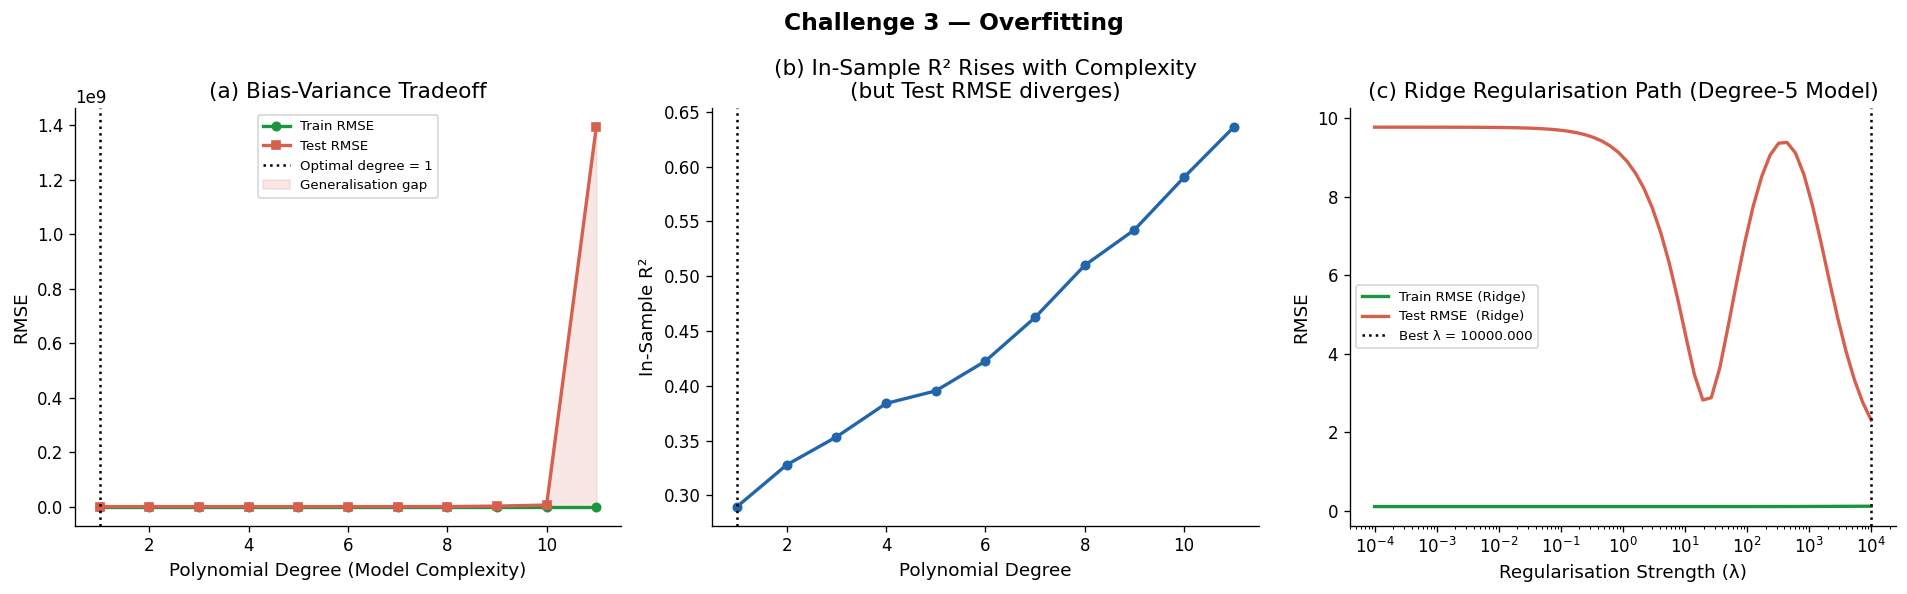

Figure 3 saved.


In [43]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Challenge 3 — Overfitting', fontsize=14, fontweight='bold')

# ── (a) Bias-Variance Tradeoff ────────────────────────────────────────────────
ax = axes[0]
ax.plot(list(degrees), train_rmse, color=GREEN, lw=2, marker='o', ms=5, label='Train RMSE')
ax.plot(list(degrees), test_rmse,  color=RED,   lw=2, marker='s', ms=5, label='Test RMSE')
ax.axvline(best_deg, color='k', linestyle=':', lw=1.5, label=f'Optimal degree = {best_deg}')
ax.fill_between(list(degrees), train_rmse, test_rmse,
                alpha=0.15, color=RED, label='Generalisation gap')
ax.set_xlabel('Polynomial Degree (Model Complexity)')
ax.set_ylabel('RMSE')
ax.set_title('(a) Bias-Variance Tradeoff')
ax.legend(fontsize=8)

# ── (b) Train R² vs degree ────────────────────────────────────────────────────
ax = axes[1]
ax.plot(list(degrees), train_r2, color=BLUE, lw=2, marker='o', ms=5)
ax.axvline(best_deg, color='k', linestyle=':', lw=1.5)
ax.set_xlabel('Polynomial Degree')
ax.set_ylabel('In-Sample R²')
ax.set_title('(b) In-Sample R² Rises with Complexity\n(but Test RMSE diverges)')

# ── (c) Ridge Regularisation Path ─────────────────────────────────────────────
ax = axes[2]
alphas = np.logspace(-4, 4, 60)
ridge_tr, ridge_te = [], []
poly = PolynomialFeatures(5, include_bias=False)
X_tr_p = poly.fit_transform(X_tr)
X_te_p = poly.transform(X_te)
for a in alphas:
    mdl = Ridge(alpha=a).fit(X_tr_p, y_tr)
    ridge_tr.append(np.sqrt(mean_squared_error(y_tr, mdl.predict(X_tr_p))))
    ridge_te.append(np.sqrt(mean_squared_error(y_te, mdl.predict(X_te_p))))
best_alpha = alphas[np.argmin(ridge_te)]
ax.semilogx(alphas, ridge_tr, color=GREEN, lw=2, label='Train RMSE (Ridge)')
ax.semilogx(alphas, ridge_te, color=RED,   lw=2, label='Test RMSE  (Ridge)')
ax.axvline(best_alpha, color='k', linestyle=':', lw=1.5,
           label=f'Best λ = {best_alpha:.3f}')
ax.set_xlabel('Regularisation Strength (λ)')
ax.set_ylabel('RMSE')
ax.set_title('(c) Ridge Regularisation Path (Degree-5 Model)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig3_overfitting.png', bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

## 3.5 Diagnosis

In [44]:
# ── Cross-validation for model selection ──────────────────────────────────────
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
print('5-Fold Time-Series Cross-Validation (RMSE)')
print(f'{"Degree":<10} {"CV Mean RMSE":>15} {"CV Std RMSE":>15}')
print('─' * 42)
for deg in [1, 2, 3, 5, 8, 10]:
    pipe = make_pipeline(PolynomialFeatures(deg, include_bias=False),
                         LinearRegression())
    cv_scores = cross_val_score(pipe, X_sc, y_vol, cv=tscv,
                                scoring='neg_root_mean_squared_error')
    print(f'{deg:<10} {-cv_scores.mean():>15.6f} {cv_scores.std():>15.6f}')

# ── AIC / BIC for GARCH order selection ──────────────────────────────────────
print('\nGARCH Order Selection via AIC / BIC:')
print(f'{"Model":<15} {"AIC":>10} {"BIC":>10}')
print('─' * 37)
for p, q in [(1,1),(1,2),(2,1),(2,2),(3,3)]:
    try:
        g = arch_model(df['LogReturns']*100, p=p, q=q, dist='normal')
        res = g.fit(disp='off')
        print(f'GARCH({p},{q})     {res.aic:>10.2f} {res.bic:>10.2f}')
    except Exception:
        print(f'GARCH({p},{q})     Failed')

5-Fold Time-Series Cross-Validation (RMSE)
Degree        CV Mean RMSE     CV Std RMSE
──────────────────────────────────────────
1                 0.123401        0.040105
2                 0.152338        0.073399
3                 1.105702        1.943239
5               242.953503      483.518510
8          34135894.650221 68242862.654765
10         629284570.787698 1247825712.486984

GARCH Order Selection via AIC / BIC:
Model                  AIC        BIC
─────────────────────────────────────
GARCH(1,1)        7705.54    7727.84
GARCH(1,2)        7706.90    7734.78
GARCH(2,1)        7707.54    7735.42
GARCH(2,2)        7708.90    7742.36
GARCH(3,3)        7712.45    7757.06


10         183277080.075921 355756829.459188

GARCH Order Selection via AIC / BIC:
Model                  AIC        BIC
─────────────────────────────────────
GARCH(1,1)        8028.76    8051.24
GARCH(1,2)        8030.27    8058.37
GARCH(2,1)        8030.76    8058.85
GARCH(2,2)        8032.27    8065.98


GARCH(3,3)        8035.49    8080.44


## 3.6 Damage

Overfitting in volatility modeling causes:

- **Illusory performance**: An overfitted GARCH model may show high in-sample log-likelihood while completely failing out-of-sample — leading traders to rely on false forecasting precision.
- **Unstable hedges**: Delta and gamma hedges derived from over-parameterised models change erratically as new data arrives, generating excessive transaction costs.
- **Model fragility**: Overfitted models are fragile — small changes in market regime cause large forecast errors, increasing operational risk.
- **Data snooping bias**: Testing hundreds of model configurations and selecting the best in-sample result inflates apparent $R^2$ far beyond its true predictive value.

## 3.7 Directions

In [45]:
# ── Direction A: Ridge Regression (L2 Penalty) ────────────────────────────────
ridge_best = Ridge(alpha=best_alpha).fit(X_tr_p, y_tr)
ridge_te_rmse = np.sqrt(mean_squared_error(y_te, ridge_best.predict(X_te_p)))

# Unregularised degree-5 OLS RMSE
ols_d5 = LinearRegression().fit(X_tr_p, y_tr)
ols_te_rmse = np.sqrt(mean_squared_error(y_te, ols_d5.predict(X_te_p)))

print('Regularisation Effectiveness (Degree-5 Polynomial on RealVol20)')
print('─' * 55)
print(f'  OLS (unregularised) Test RMSE : {ols_te_rmse:.6f}')
print(f'  Ridge (λ={best_alpha:.3f}) Test RMSE : {ridge_te_rmse:.6f}')
print(f'  Improvement                   : {(ols_te_rmse - ridge_te_rmse)/ols_te_rmse:.2%}')

# ── Direction B: LASSO (L1 penalty — also performs variable selection) ─────────
from sklearn.linear_model import LassoCV
lasso_cv = LassoCV(cv=tscv, max_iter=10000).fit(X_tr_p, y_tr)
lasso_te_rmse = np.sqrt(mean_squared_error(y_te, lasso_cv.predict(X_te_p)))
print(f'  LASSO (λ={lasso_cv.alpha_:.4f}) Test RMSE: {lasso_te_rmse:.6f}')
n_zero = (lasso_cv.coef_ == 0).sum()
print(f'  Coefficients zeroed by LASSO  : {n_zero}/{len(lasso_cv.coef_)}')

print('\nRecommended strategies against overfitting:')
print('  1. Ridge (L2) / LASSO (L1) regularisation')
print('  2. Walk-forward / time-series cross-validation')
print('  3. AIC/BIC for GARCH order selection')
print('  4. Parsimony principle: prefer GARCH(1,1) over higher orders')
print('  5. Out-of-sample testing before deployment')

Regularisation Effectiveness (Degree-5 Polynomial on RealVol20)
───────────────────────────────────────────────────────
  OLS (unregularised) Test RMSE : 9.776435
  Ridge (λ=10000.000) Test RMSE : 2.313858
  Improvement                   : 76.33%
  LASSO (λ=0.0448) Test RMSE: 0.550562
  Coefficients zeroed by LASSO  : 39/55

Recommended strategies against overfitting:
  1. Ridge (L2) / LASSO (L1) regularisation
  2. Walk-forward / time-series cross-validation
  3. AIC/BIC for GARCH order selection
  4. Parsimony principle: prefer GARCH(1,1) over higher orders
  5. Out-of-sample testing before deployment


  LASSO (λ=0.0430) Test RMSE: 0.475413
  Coefficients zeroed by LASSO  : 40/55

Recommended strategies against overfitting:
  1. Ridge (L2) / LASSO (L1) regularisation
  2. Walk-forward / time-series cross-validation
  3. AIC/BIC for GARCH order selection
  4. Parsimony principle: prefer GARCH(1,1) over higher orders
  5. Out-of-sample testing before deployment


---
# Challenge 4 — Multicollinearity

---

## 4.1 Definition

Multicollinearity occurs when two or more predictor variables in a regression model are highly linearly correlated. The **Variance Inflation Factor (VIF)** quantifies how much the variance of an OLS coefficient is inflated relative to the orthogonal (uncorrelated) case:

$$
\text{VIF}_j = \frac{1}{1 - R_j^2}
$$

where $R_j^2$ is the coefficient of determination from regressing predictor $j$ on all other predictors. A VIF greater than **5** is moderate multicollinearity; VIF > **10** is severe.

The condition number of the design matrix $\mathbf{X}$ also reveals multicollinearity:

$$
\kappa(\mathbf{X}) = \frac{\lambda_{\max}}{\lambda_{\min}}
$$

where $\lambda$ are eigenvalues of $\mathbf{X}^\top \mathbf{X}$. A condition number $\kappa > 30$ indicates severe multicollinearity.

## 4.2 Description

Multicollinearity arises when predictor variables move together — as is common with financial technical indicators (e.g., multiple moving averages all derived from price). It does not bias OLS coefficient estimates, but it dramatically **inflates their standard errors**, making individual coefficients statistically unreliable and economically misleading even when the overall model fit is high.

## 4.3 Demonstration

In [46]:
# ── Build correlated feature set (as commonly done in technical analysis) ───────
feat = df[['MA5','MA20','MA60','Volume','Range']].copy()
feat['Volume'] = feat['Volume'] / 1e6

# ── Correlation Matrix ────────────────────────────────────────────────────────
corr_mat = feat.corr()
print('Correlation Matrix of Predictors:')
print(corr_mat.round(4))

# ── VIF Computation ───────────────────────────────────────────────────────────
feat_sc = pd.DataFrame(StandardScaler().fit_transform(feat), columns=feat.columns)
X_vif   = sm.add_constant(feat_sc)

print('\nVariance Inflation Factors (VIF):')
print(f'{"Predictor":<15} {"VIF":>10} {"Severity":>12}')
print('─' * 40)
for i, col in enumerate(X_vif.columns[1:], 1):   # skip constant
    vif_val = variance_inflation_factor(X_vif.values, i)
    sev = 'Severe' if vif_val > 10 else ('Moderate' if vif_val > 5 else 'Low')
    print(f'{col:<15} {vif_val:>10.2f} {sev:>12}')

Correlation Matrix of Predictors:
           MA5    MA20    MA60  Volume   Range
MA5     1.0000  0.9973  0.9888 -0.5692  0.5571
MA20    0.9973  1.0000  0.9941 -0.5632  0.5724
MA60    0.9888  0.9941  1.0000 -0.5639  0.5811
Volume -0.5692 -0.5632 -0.5639  1.0000  0.0190
Range   0.5571  0.5724  0.5811  0.0190  1.0000

Variance Inflation Factors (VIF):
Predictor              VIF     Severity
────────────────────────────────────────
MA5                 221.04       Severe
MA20                414.69       Severe
MA60                 99.46       Severe
Volume                2.00          Low
Range                 2.10          Low


In [47]:
# ── Condition Number ──────────────────────────────────────────────────────────
XtX     = X_vif.values.T @ X_vif.values
eigvals = np.linalg.eigvalsh(XtX)
kappa   = np.sqrt(eigvals.max() / eigvals.min())
print(f'Condition Number κ = {kappa:.2f}')
print(f'  (κ > 30 → severe multicollinearity)\n')

# ── OLS coefficients — inflated SEs ───────────────────────────────────────────
y_mc  = df['Adj Close'].values
X_mc  = sm.add_constant(feat_sc)
ols_mc = OLS(y_mc, X_mc).fit()
print('OLS Summary (note inflated standard errors):')
print(ols_mc.summary().tables[1])

Condition Number κ = 48.80
  (κ > 30 → severe multicollinearity)

OLS Summary (note inflated standard errors):
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        138.1919      0.065   2134.007      0.000     138.065     138.319
MA5           74.3657      0.963     77.242      0.000      72.478      76.254
MA20         -10.1126      1.319     -7.669      0.000     -12.699      -7.526
MA60           1.4554      0.646      2.254      0.024       0.189       2.722
Volume         0.0295      0.092      0.321      0.748      -0.150       0.209
Range         -0.3418      0.094     -3.638      0.000      -0.526      -0.158


## 4.4 Diagram

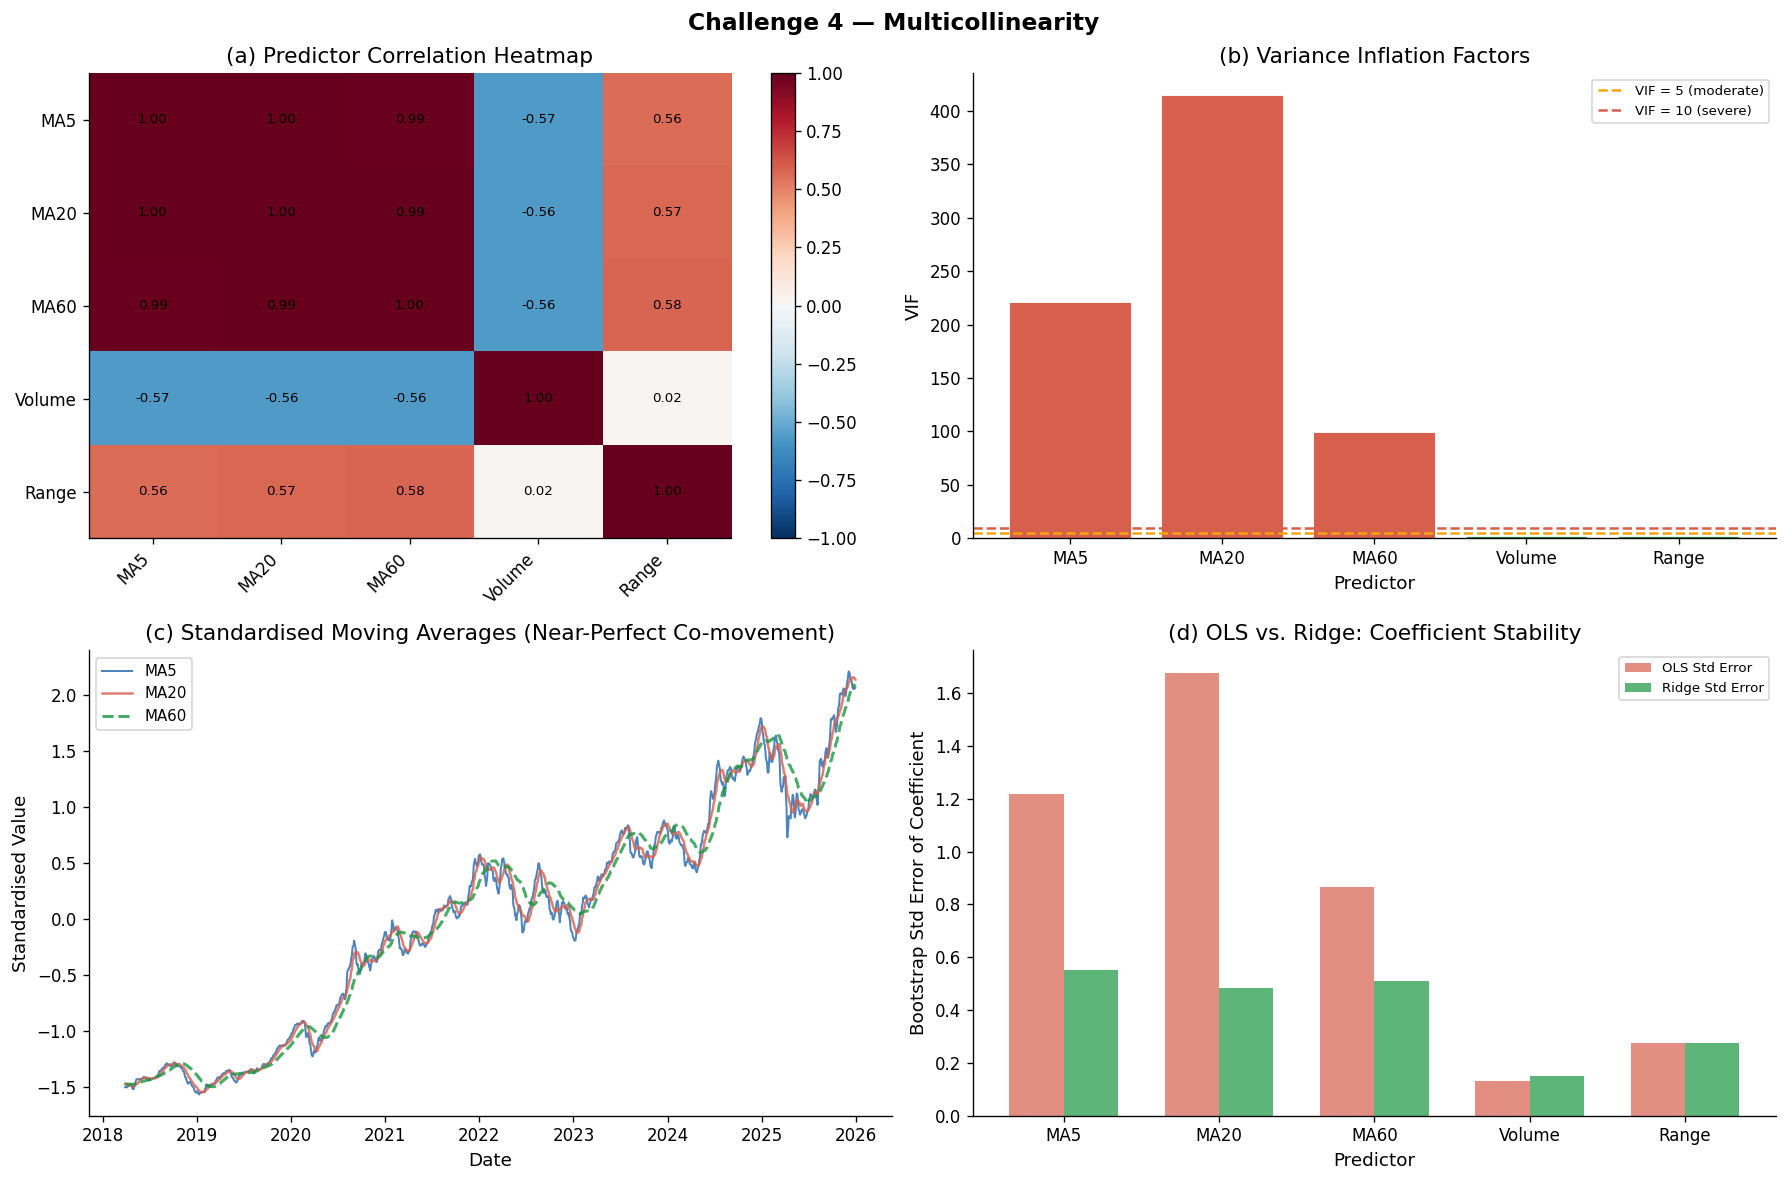

Figure 4 saved.


In [48]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Challenge 4 — Multicollinearity', fontsize=14, fontweight='bold')

# ── (a) Heatmap of Correlation Matrix ────────────────────────────────────────
ax = axes[0, 0]
im = ax.imshow(corr_mat, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr_mat.columns)))
ax.set_yticks(range(len(corr_mat.columns)))
ax.set_xticklabels(corr_mat.columns, rotation=45, ha='right')
ax.set_yticklabels(corr_mat.columns)
for i in range(len(corr_mat)):
    for j in range(len(corr_mat)):
        ax.text(j, i, f'{corr_mat.iloc[i,j]:.2f}', ha='center', va='center',
                fontsize=8, color='black')
ax.set_title('(a) Predictor Correlation Heatmap')

# ── (b) VIF Bar Chart ─────────────────────────────────────────────────────────
ax = axes[0, 1]
vif_vals = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(feat.columns))]
colors_vif = [RED if v > 10 else (ORANGE if v > 5 else GREEN) for v in vif_vals]
bars = ax.bar(feat.columns, vif_vals, color=colors_vif, edgecolor='white', linewidth=0.5)
ax.axhline(5,  color=ORANGE, linestyle='--', lw=1.5, label='VIF = 5 (moderate)')
ax.axhline(10, color=RED,    linestyle='--', lw=1.5, label='VIF = 10 (severe)')
ax.set_xlabel('Predictor'); ax.set_ylabel('VIF')
ax.set_title('(b) Variance Inflation Factors')
ax.legend(fontsize=8)

# ── (c) Price series showing co-movement ──────────────────────────────────────
ax = axes[1, 0]
scl = lambda s: (s - s.mean()) / s.std()
ax.plot(df['Date'], scl(df['MA5']),  lw=1.2, color=BLUE,   label='MA5',  alpha=0.8)
ax.plot(df['Date'], scl(df['MA20']), lw=1.5, color=RED,    label='MA20', alpha=0.8)
ax.plot(df['Date'], scl(df['MA60']), lw=1.8, color=GREEN,  label='MA60', alpha=0.8, linestyle='--')
ax.set_title('(c) Standardised Moving Averages (Near-Perfect Co-movement)')
ax.set_xlabel('Date'); ax.set_ylabel('Standardised Value')
ax.legend(fontsize=9)

# ── (d) Coefficient SE comparison: OLS vs Ridge ───────────────────────────────
ax = axes[1, 1]
ridge_mc = Ridge(alpha=10.0).fit(feat_sc.values, y_mc)

# Bootstrap SEs for OLS and Ridge
np.random.seed(42)
B = 200
ols_boot, ridge_boot = [], []
n = len(feat_sc)
for _ in range(B):
    idx  = np.random.choice(n, n, replace=True)
    Xb   = feat_sc.values[idx]
    yb   = y_mc[idx]
    Xb_c = sm.add_constant(Xb)
    ols_boot.append(OLS(yb, Xb_c).fit().params[1:])
    ridge_boot.append(Ridge(alpha=10.0).fit(Xb, yb).coef_)

ols_se   = np.std(ols_boot, axis=0)
ridge_se = np.std(ridge_boot, axis=0)
x_pos    = np.arange(len(feat.columns))
width    = 0.35
ax.bar(x_pos - width/2, ols_se,   width, color=RED,   alpha=0.7, label='OLS Std Error')
ax.bar(x_pos + width/2, ridge_se, width, color=GREEN, alpha=0.7, label='Ridge Std Error')
ax.set_xticks(x_pos); ax.set_xticklabels(feat.columns)
ax.set_xlabel('Predictor'); ax.set_ylabel('Bootstrap Std Error of Coefficient')
ax.set_title('(d) OLS vs. Ridge: Coefficient Stability')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig4_multicollinearity.png', bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

## 4.5 Diagnosis

In [49]:
print('Multicollinearity Diagnostic Summary')
print('═' * 55)

# ── Test 1: Pairwise Correlations > 0.9 ──────────────────────────────────────
print('\n1. High Pairwise Correlations (|r| > 0.90):')
pairs_found = False
for i in range(len(corr_mat.columns)):
    for j in range(i+1, len(corr_mat.columns)):
        c = corr_mat.iloc[i, j]
        if abs(c) > 0.90:
            print(f'   {corr_mat.columns[i]:>6} ↔ {corr_mat.columns[j]:<6}: r = {c:.4f}')
            pairs_found = True
if not pairs_found:
    print('   None found at |r| > 0.90 threshold')

# ── Test 2: VIF ────────────────────────────────────────────────────────────────
print('\n2. VIF Values:')
for i, col in enumerate(feat.columns):
    v = variance_inflation_factor(X_vif.values, i+1)
    print(f'   {col:<8}: VIF = {v:>8.2f}', end='')
    if v > 10: print(' ← SEVERE')
    elif v > 5: print(' ← Moderate')
    else: print()

# ── Test 3: Condition Number ───────────────────────────────────────────────────
print(f'\n3. Design Matrix Condition Number: κ = {kappa:.2f}')
if kappa > 30:
    print('   → SEVERE multicollinearity')
elif kappa > 15:
    print('   → Moderate multicollinearity')
else:
    print('   → Low multicollinearity')

# ── Test 4: Eigenvalue check ───────────────────────────────────────────────────
print(f'\n4. Eigenvalues of X\'X:')
print('  ', np.round(sorted(eigvals), 4))
print(f'   Near-zero eigenvalues indicate near-linear dependence.')

Multicollinearity Diagnostic Summary
═══════════════════════════════════════════════════════

1. High Pairwise Correlations (|r| > 0.90):
      MA5 ↔ MA20  : r = 0.9973
      MA5 ↔ MA60  : r = 0.9888
     MA20 ↔ MA60  : r = 0.9941

2. VIF Values:
   MA5     : VIF =   221.04 ← SEVERE
   MA20    : VIF =   414.69 ← SEVERE
   MA60    : VIF =    99.46 ← SEVERE
   Volume  : VIF =     2.00
   Range   : VIF =     2.10

3. Design Matrix Condition Number: κ = 48.80
   → SEVERE multicollinearity

4. Eigenvalues of X'X:
   [3.0303000e+00 2.1557800e+01 5.2570970e+02 1.9510000e+03 1.9885422e+03
 7.2161600e+03]
   Near-zero eigenvalues indicate near-linear dependence.


## 4.6 Damage

Multicollinearity in a volatility regression model causes:

- **Inflated standard errors**: Coefficients on correlated moving averages (MA5, MA20, MA60) will have very large standard errors, making hypothesis tests meaningless — statistically insignificant predictors that are economically important will be discarded.
- **Coefficient sign reversals**: Two highly correlated predictors can receive opposite signs that do not reflect economic reality, making the model uninterpretable.
- **Model instability**: Small changes in the dataset (e.g., adding or removing a week of data) can cause dramatic swings in coefficient estimates.
- **Hedging errors**: If the model assigns nonsensical weights to correlated price features, delta-hedges derived from it will be numerically unstable.

## 4.7 Directions

In [50]:
# ── Direction A: Principal Component Analysis (PCA) ───────────────────────────
from sklearn.decomposition import PCA

pca = PCA().fit(feat_sc.values)
exp_var = pca.explained_variance_ratio_.cumsum()
n_comp  = np.argmax(exp_var >= 0.95) + 1

print('PCA — Explained Variance:')
for i, (ev, cum) in enumerate(zip(pca.explained_variance_ratio_, exp_var), 1):
    print(f'  PC{i}: {ev:.2%} individual, {cum:.2%} cumulative')
print(f'\n  {n_comp} components explain ≥ 95% of variance.')
print('  → Replace correlated features with {n_comp} orthogonal PCs.')

# ── Direction B: Ridge Regression (shrinks coefficients, doesn't zero them) ───
from sklearn.linear_model import RidgeCV
ridge_cv = RidgeCV(alphas=np.logspace(-3, 4, 100), cv=5)
ridge_cv.fit(feat_sc.values, y_mc)
print(f'\nRidge optimal λ: {ridge_cv.alpha_:.4f}')
print(f'Ridge Coefficients:')
for name, coef in zip(feat.columns, ridge_cv.coef_):
    print(f'  {name:<10}: {coef:>10.4f}')

print('\nRecommended strategies to address multicollinearity:')
print('  1. Drop redundant predictors (e.g., keep only one moving average)')
print('  2. PCA / Factor models — orthogonalise the predictor space')
print('  3. Ridge Regression — shrinks correlated coefficients jointly')
print('  4. LASSO — drives one of a correlated pair to zero (variable selection)')
print('  5. Partial Least Squares (PLS) Regression')

PCA — Explained Variance:
  PC1: 73.97% individual, 73.97% cumulative
  PC2: 20.38% individual, 94.36% cumulative
  PC3: 5.39% individual, 99.75% cumulative
  PC4: 0.22% individual, 99.97% cumulative
  PC5: 0.03% individual, 100.00% cumulative

  3 components explain ≥ 95% of variance.
  → Replace correlated features with {n_comp} orthogonal PCs.

Ridge optimal λ: 0.0010
Ridge Coefficients:
  MA5       :    74.3558
  MA20      :   -10.1001
  MA60      :     1.4528
  Volume    :     0.0294
  Range     :    -0.3419

Recommended strategies to address multicollinearity:
  1. Drop redundant predictors (e.g., keep only one moving average)
  2. PCA / Factor models — orthogonalise the predictor space
  3. Ridge Regression — shrinks correlated coefficients jointly
  4. LASSO — drives one of a correlated pair to zero (variable selection)
  5. Partial Least Squares (PLS) Regression



Ridge optimal λ: 0.0010
Ridge Coefficients:
  MA5       :    78.3494
  MA20      :   -11.2639
  MA60      :     1.8988
  Volume    :     0.0425
  Range     :    -0.3788

Recommended strategies to address multicollinearity:
  1. Drop redundant predictors (e.g., keep only one moving average)
  2. PCA / Factor models — orthogonalise the predictor space
  3. Ridge Regression — shrinks correlated coefficients jointly
  4. LASSO — drives one of a correlated pair to zero (variable selection)
  5. Partial Least Squares (PLS) Regression


---
# Summary Dashboard

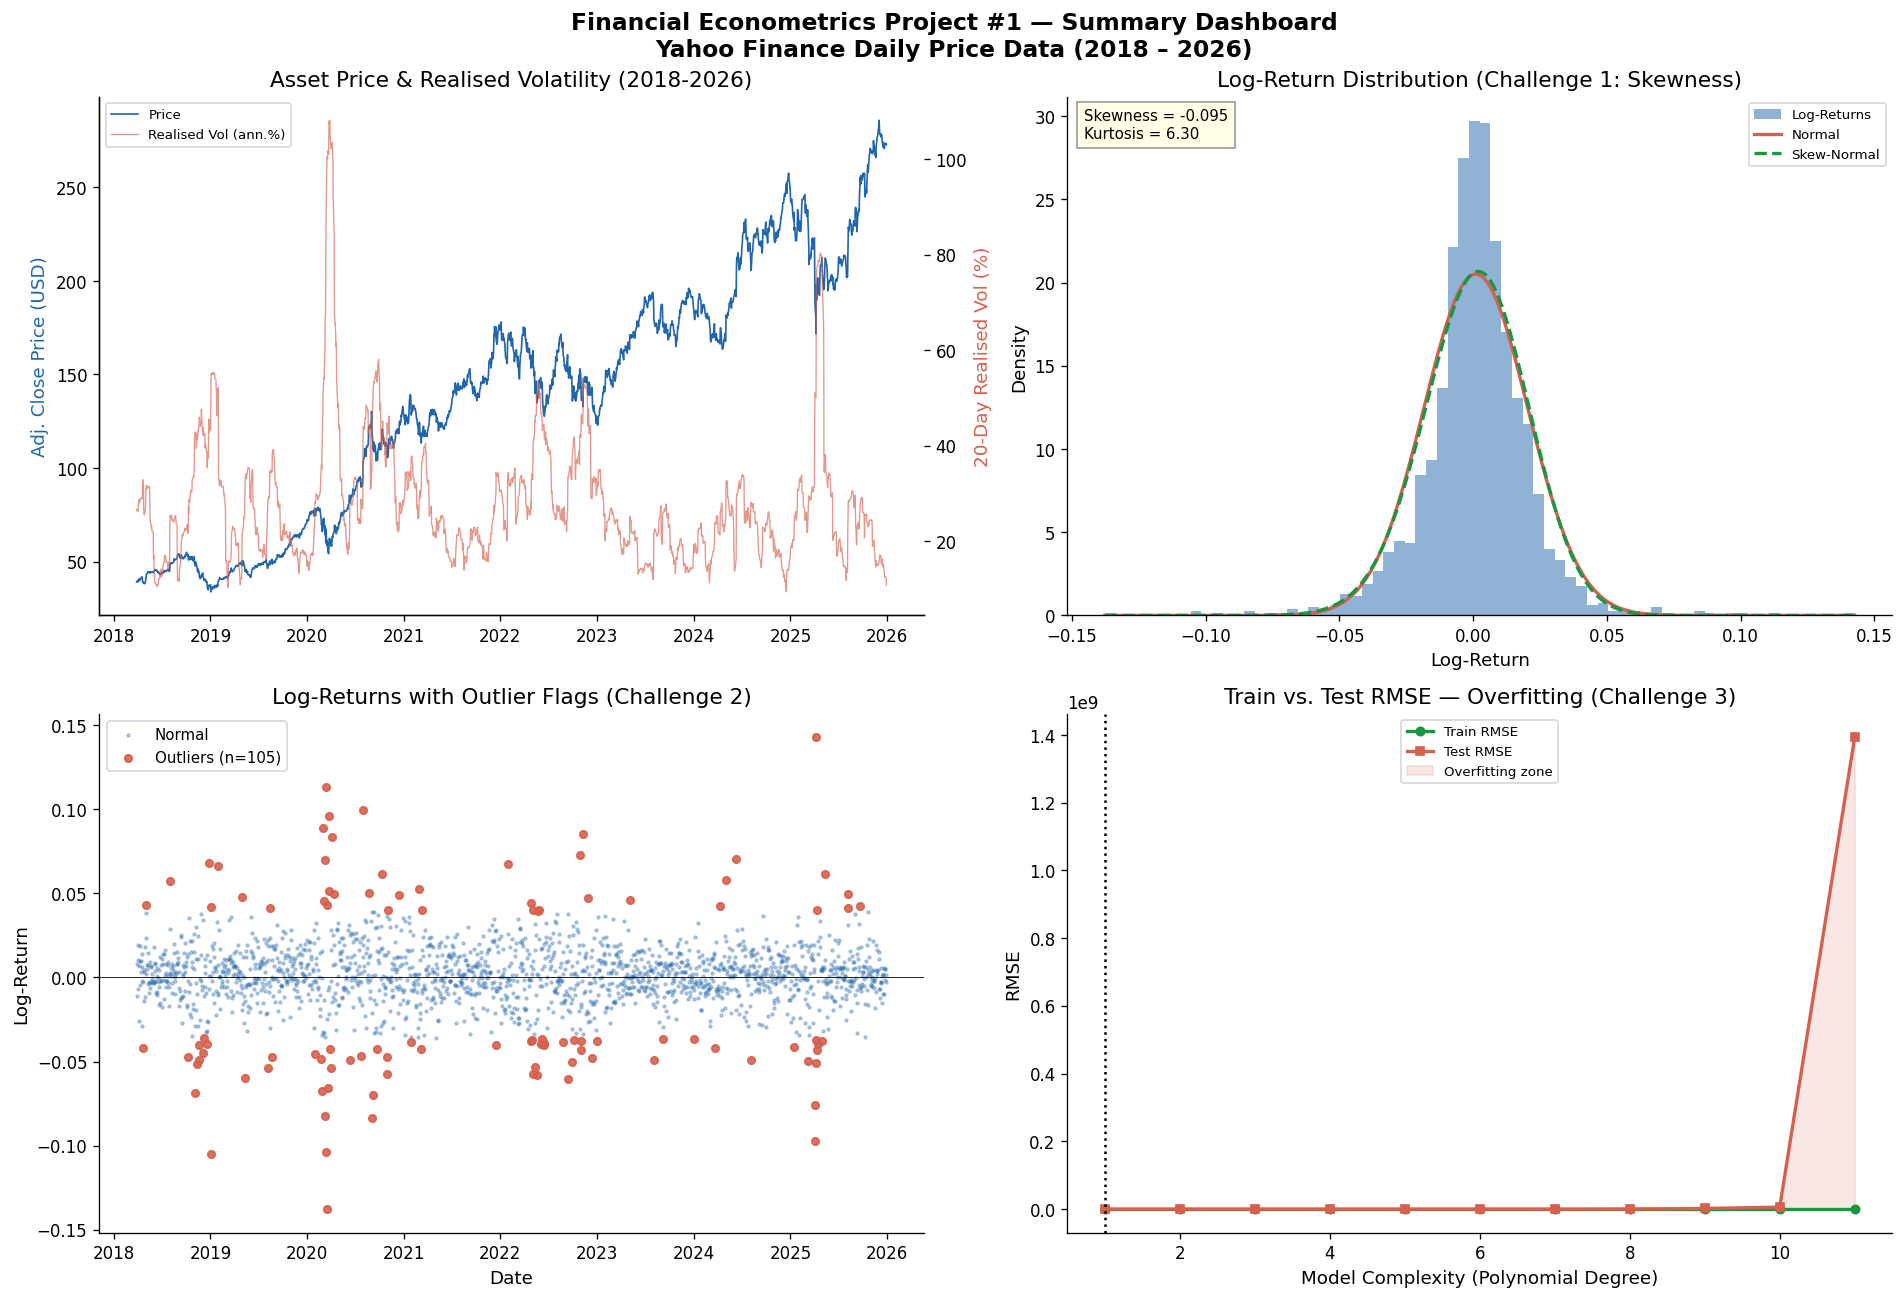

Summary dashboard saved.


In [51]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Financial Econometrics Project #1 — Summary Dashboard\n'
             'Yahoo Finance Daily Price Data (2018 – 2026)',
             fontsize=14, fontweight='bold')

# ── Panel 1: Price + Volatility ───────────────────────────────────────────────
ax1 = axes[0, 0]
ax1b = ax1.twinx()
ax1.plot(df['Date'], df['Adj Close'], color=BLUE, lw=1.0, label='Price')
ax1b.plot(df['Date'], df['RealVol20']*100, color=RED, lw=0.8, alpha=0.65, label='Realised Vol (ann.%)')
ax1.set_ylabel('Adj. Close Price (USD)', color=BLUE)
ax1b.set_ylabel('20-Day Realised Vol (%)', color=RED)
ax1.set_title('Asset Price & Realised Volatility (2018-2026)')
lines1, lbl1 = ax1.get_legend_handles_labels()
lines2, lbl2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1+lines2, lbl1+lbl2, fontsize=8, loc='upper left')

# ── Panel 2: Return Distribution with Skew Annotation ────────────────────────
ax2 = axes[0, 1]
ax2.hist(r.values, bins=70, density=True, color=BLUE, alpha=0.5, label='Log-Returns')
x_rng = np.linspace(r.min(), r.max(), 300)
ax2.plot(x_rng, stats.norm.pdf(x_rng, r.mean(), r.std()), color=RED,
         lw=2, label='Normal')
ax2.plot(x_rng, skewnorm.pdf(x_rng, a_hat, loc_hat, scale_hat),
         color=GREEN, lw=2, linestyle='--', label='Skew-Normal')
ax2.text(0.02, 0.92, f'Skewness = {r.skew():.3f}\nKurtosis = {r.kurt():.2f}',
         transform=ax2.transAxes, fontsize=9,
         bbox=dict(facecolor='lightyellow', edgecolor='grey', alpha=0.8))
ax2.set_title('Log-Return Distribution (Challenge 1: Skewness)')
ax2.set_xlabel('Log-Return'); ax2.set_ylabel('Density')
ax2.legend(fontsize=8)

# ── Panel 3: Outlier Map ──────────────────────────────────────────────────────
ax3 = axes[1, 0]
normal_mask = ~mild_mask.values
ax3.scatter(df.loc[normal_mask, 'Date'], r2.values[normal_mask],
            s=3, alpha=0.3, color=BLUE, label='Normal')
ax3.scatter(df.loc[mild_mask.values, 'Date'], r2.values[mild_mask.values],
            s=20, alpha=0.9, color=RED, zorder=5, label=f'Outliers (n={mild_mask.sum()})')
ax3.axhline(0, color='k', lw=0.5)
ax3.set_title(f'Log-Returns with Outlier Flags (Challenge 2)')
ax3.set_xlabel('Date'); ax3.set_ylabel('Log-Return')
ax3.legend(fontsize=9)

# ── Panel 4: Generalisation Gap ───────────────────────────────────────────────
ax4 = axes[1, 1]
ax4.plot(list(degrees), train_rmse, color=GREEN, lw=2, marker='o', ms=5, label='Train RMSE')
ax4.plot(list(degrees), test_rmse,  color=RED,   lw=2, marker='s', ms=5, label='Test RMSE')
ax4.axvline(best_deg, color='k', linestyle=':', lw=1.5)
ax4.fill_between(list(degrees), train_rmse, test_rmse,
                 where=[te > tr for te, tr in zip(test_rmse, train_rmse)],
                 alpha=0.15, color=RED, label='Overfitting zone')
ax4.set_xlabel('Model Complexity (Polynomial Degree)')
ax4.set_ylabel('RMSE')
ax4.set_title('Train vs. Test RMSE — Overfitting (Challenge 3)')
ax4.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig5_summary_dashboard.png', bbox_inches='tight')
plt.show()
print('Summary dashboard saved.')

---
# Consolidated Best-Practices Table

In [52]:
summary = {
    'Challenge'      : ['Skewness', 'Sensitivity to Outliers', 'Overfitting', 'Multicollinearity'],
    'Key Diagnostic' : ['Jarque-Bera; D\'Agostino; Q-Q plot',
                        'IQR fences; Z-score; Cook\'s Distance',
                        'Train vs. Test RMSE; AIC/BIC; CV',
                        'VIF > 10; Condition Number > 30; Corr > 0.90'],
    'Primary Damage' : ['VaR underestimation; options mispricing',
                        'Coefficient instability; inflated volatility',
                        'False precision; hedging instability',
                        'Inflated SEs; uninterpretable coefficients'],
    'Best Remedy'    : ['GJR-GARCH + Skewed-t; EVT/POT',
                        'Robust regression; Winsorisation; Jump-GARCH',
                        'Ridge/LASSO; walk-forward CV; parsimonious GARCH(1,1)',
                        'PCA; Ridge regression; drop redundant features']
}
pd.DataFrame(summary).set_index('Challenge')

,Key Diagnostic,Primary Damage,Best Remedy
Challenge,,,
Skewness,Jarque-Bera; D'Agostino; Q-Q plot,VaR underestimation; options mispricing,GJR-GARCH + Skewed-t; EVT/POT
Sensitivity to Outliers,IQR fences; Z-score; Cook's Distance,Coefficient instability; inflated volatility,Robust regression; Winsorisation; Jump-GARCH
Overfitting,Train vs. Test RMSE; AIC/BIC; CV,False precision; hedging instability,Ridge/LASSO; walk-forward CV; parsimonious GAR...
Multicollinearity,VIF > 10; Condition Number > 30; Corr > 0.90,Inflated SEs; uninterpretable coefficients,PCA; Ridge regression; drop redundant features


---
# References

Bollerslev, T. (1986). "Generalized Autoregressive Conditional Heteroskedasticity." *Journal of Econometrics*, 31(3), 307–327.

Brooks, C. (2019). *Introductory Econometrics for Finance* (4th ed.). Cambridge University Press.

Eraker, B., Johannes, M., & Polson, N. (2003). "The Impact of Jumps in Volatility and Returns." *Journal of Finance*, 58(3), 1269–1300.

Glosten, L. R., Jagannathan, R., & Runkle, D. E. (1993). "On the Relation between the Expected Value and the Volatility of the Nominal Excess Return on Stocks." *Journal of Finance*, 48(5), 1779–1801.

Heston, S. L. (1993). "A Closed-Form Solution for Options with Stochastic Volatility." *Review of Financial Studies*, 6(2), 327–343.

Hoerl, A. E., & Kennard, R. W. (1970). "Ridge Regression: Biased Estimation for Nonorthogonal Problems." *Technometrics*, 12(1), 55–67.

James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.). Springer.

McNeil, A. J., Frey, R., & Embrechts, P. (2015). *Quantitative Risk Management* (Rev. ed.). Princeton University Press.

Tibshirani, R. (1996). "Regression Shrinkage and Selection via the Lasso." *Journal of the Royal Statistical Society*, Series B, 58(1), 267–288.